# PCB Defect Detection — Quantum Detection Head + YOLOv8
**Hybrid Quantum-Classical Object Detection on DeepPCB Dataset**

Key improvements in this version:
- **Drive-backed resumable training** — session crash → re-run, training resumes from last epoch
- Unified `CheckpointManager` saves every N epochs + best model to Drive
- `train_head()` accepts `resume=True` to load the latest Drive checkpoint automatically
- Redundant per-section pickle checkpoints consolidated into a single state file
- `QuantumDetectionHead` rebuilt with LayerNorm projection for training stability

| Section | Description |
|---|---|
| 1 | Install & Imports |
| 2 | Mount Drive & Checkpoint Manager |
| 3 | Download Dataset |
| 4 | Parse Annotations & EDA |
| 5 | Difference Imaging |
| 6 | Convert to YOLO Format |
| 7 | Dataset YAML |
| 8 | Train Classical YOLOv8x (baseline) |
| 9 | Extract Per-Box Features |
| 10 | Quantum Detection Head |
| 11 | Train Quantum + Classical Heads (resumable) |
| 12 | Evaluate & Compare |
| 13 | Inference & Visualize |
| 14 | Export |


## Section 1 — Install & Imports

In [1]:
!pip install ultralytics opencv-python matplotlib seaborn pandas tqdm pyyaml -q
!pip install pennylane -q
!pip install scikit-learn -q

import os, random, yaml, warnings, time, pickle, json, shutil
from pathlib import Path
from collections import defaultdict
from datetime import datetime

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import pennylane as qml

warnings.filterwarnings('ignore')

DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"PyTorch     : {torch.__version__}")
print(f"CUDA        : {torch.cuda.is_available()}")
print(f"PennyLane   : {qml.__version__}")
print(f"Device      : {DEVICE}")

from ultralytics import YOLO
print('✅ All packages loaded.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 39.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 81.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 935.6/935.6 kB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 79.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 94.5 MB/s eta 0:00:00
PyTorch     : 2.10.0+cu128
CUDA        : True
PennyLane   : 0.44.1
Device      : cuda
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart

## Section 2 — Persistent Storage & Checkpoint Manager

**Kaggle** uses `/kaggle/working/` as the persistent working directory.  
Checkpoints are saved there and survive across sessions **as long as you save
the notebook** (Kaggle auto-saves outputs).  No Drive mount needed.

> **How resume works:** Every time you re-run this notebook, `CheckpointManager`
> looks in `/kaggle/working/checkpoints/` for existing `.pt` / `.npz` / `.pkl`
> files and skips any stage that already completed.


In [2]:
# ══════════════════════════════════════════════════════════════════════════════
# Persistent storage root — works on Kaggle and Colab
# ══════════════════════════════════════════════════════════════════════════════
import os

def _detect_env():
    if os.path.exists('/kaggle/working'):
        return 'kaggle', Path('/kaggle/working/checkpoints')
    elif os.path.exists('/content'):
        # Colab without Drive — use local /content
        return 'colab_local', Path('/content/checkpoints')
    else:
        return 'local', Path('checkpoints')

ENV, CKPT_ROOT = _detect_env()
CKPT_ROOT.mkdir(parents=True, exist_ok=True)

print(f"✓ Environment   : {ENV}")
print(f"✓ Checkpoint dir: {CKPT_ROOT}")
print()
print("ℹ  On Kaggle: checkpoints persist in /kaggle/working/ across sessions.")
print("   Re-run the notebook to resume — completed stages are skipped automatically.")


✓ Environment   : kaggle
✓ Checkpoint dir: /kaggle/working/checkpoints

ℹ  On Kaggle: checkpoints persist in /kaggle/working/ across sessions.
   Re-run the notebook to resume — completed stages are skipped automatically.


In [3]:
# ══════════════════════════════════════════════════════════════════════════════
# Unified CheckpointManager  (Kaggle / Colab compatible, no Drive required)
# ══════════════════════════════════════════════════════════════════════════════

class CheckpointManager:
    """
    Saves all artefacts under CKPT_ROOT (persistent on Kaggle).
    On Kaggle, /kaggle/working/ persists between sessions — no Drive needed.

    Naming convention
    -----------------
    - Pipeline state  : pipeline_state.pkl   (overwritten each update)
    - YOLO weights    : yolov8_best.pt
    - Feature dataset : features.npz
    - Best heads      : classical_best.pt / quantum_best.pt
    - Epoch snapshots : classical_epoch_<N>.pt  (keep last 3)
    """

    def __init__(self, root: Path):
        self.root = Path(root)
        self.root.mkdir(parents=True, exist_ok=True)

    def _p(self, name): return self.root / name

    # ── pipeline state ────────────────────────────────────────────────────────

    def save_state(self, state: dict):
        with open(self._p('pipeline_state.pkl'), 'wb') as f:
            pickle.dump(state, f)

    def load_state(self) -> dict:
        p = self._p('pipeline_state.pkl')
        if p.exists():
            with open(p, 'rb') as f:
                return pickle.load(f)
        return {}

    # ── numpy feature arrays ──────────────────────────────────────────────────

    def save_features(self, X, y):
        np.savez_compressed(self._p('features.npz'), X=X, y=y)
        print(f"✓ Features saved → {self._p('features.npz')}  "
              f"X={X.shape}  y={y.shape}")

    def load_features(self):
        p = self._p('features.npz')
        if p.exists():
            d = np.load(p)
            print(f"✓ Features loaded  X={d['X'].shape}  y={d['y'].shape}")
            return d['X'], d['y']
        return None, None

    # ── generic file copy (e.g. YOLO best.pt) ────────────────────────────────

    def save_file(self, src_path, dest_name):
        dst = self._p(dest_name)
        if Path(src_path).resolve() != dst.resolve():
            shutil.copy2(src_path, dst)
        print(f"✓ Saved → {dst}")

    def load_file(self, name):
        """Returns path if file exists, else None."""
        p = self._p(name)
        return p if p.exists() else None

    # ── PyTorch model checkpoint ──────────────────────────────────────────────

    def save_model(self, name, model, optimizer=None, scheduler=None,
                   epoch=None, metrics=None, keep_last=3):
        """Saves model + full training state.  Prunes old epoch snapshots."""
        ckpt = {'model_state_dict': model.state_dict(),
                'epoch': epoch, 'metrics': metrics or {}}
        if optimizer: ckpt['optimizer_state_dict'] = optimizer.state_dict()
        if scheduler: ckpt['scheduler_state_dict'] = scheduler.state_dict()

        p = self._p(name)
        torch.save(ckpt, p)
        print(f"  💾 Saved: {p.name}  (epoch={epoch})")

        # Prune old epoch snapshots (keep last N)
        if keep_last and 'epoch_' in name:
            stem = name.split('epoch_')[0]
            old  = sorted(self.root.glob(f"{stem}epoch_*.pt"),
                          key=lambda x: x.stat().st_mtime)[:-keep_last]
            for op in old:
                op.unlink()
                print(f"  🗑  Pruned old snapshot: {op.name}")

    def load_model(self, name, model, optimizer=None, scheduler=None):
        """Load checkpoint in-place. Returns (epoch, metrics) or (0, {})."""
        p = self._p(name)
        if not p.exists():
            return 0, {}
        ckpt = torch.load(p, map_location='cpu')
        model.load_state_dict(ckpt['model_state_dict'])
        if optimizer and 'optimizer_state_dict' in ckpt:
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        if scheduler and 'scheduler_state_dict' in ckpt:
            scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        epoch   = ckpt.get('epoch', 0) or 0
        metrics = ckpt.get('metrics', {})
        print(f"  ✓ Loaded '{name}'  epoch={epoch}")
        return epoch, metrics

    def latest_epoch_ckpt(self, prefix):
        """Return filename of the newest epoch snapshot matching prefix."""
        snaps = sorted(self.root.glob(f"{prefix}epoch_*.pt"),
                       key=lambda x: x.stat().st_mtime)
        return snaps[-1].name if snaps else None

    def list(self):
        files = sorted(self.root.iterdir())
        if not files:
            print("  (no checkpoints yet)")
            return
        print(f"\nCheckpoints in {self.root}:")
        for p in files:
            print(f"  {p.name:50s}  {p.stat().st_size/1e6:.2f} MB")


ckpt_mgr = CheckpointManager(root=CKPT_ROOT)
print("✓ CheckpointManager ready")
ckpt_mgr.list()


✓ CheckpointManager ready
  (no checkpoints yet)


## Section 3 — Download Dataset

In [4]:
import urllib.request, zipfile

DATASET_ROOT = Path('DeepPCB/PCBData')

state = ckpt_mgr.load_state()

if DATASET_ROOT.exists():
    print('✅ Dataset already exists locally.')
elif state.get('dataset_downloaded'):
    print('✅ Dataset already downloaded (state flag set).')
else:
    url      = 'https://github.com/tangsanli5201/DeepPCB/archive/refs/heads/master.zip'
    zip_path = 'DeepPCB.zip'
    print('Downloading DeepPCB dataset...')
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall('.')
    if not Path('DeepPCB').exists():
        Path('DeepPCB-master').rename('DeepPCB')
    Path(zip_path).unlink()
    state['dataset_downloaded'] = True
    ckpt_mgr.save_state(state)
    print('✅ Downloaded.')

groups = sorted([d for d in DATASET_ROOT.iterdir() if d.is_dir()])
print(f'Groups: {len(groups)}')


✅ Downloaded.
Groups: 11


## Section 4 — Parse Annotations & EDA

trainval: 1000 | test: 500 | total: 1500


Parsing: 100%|██████████| 1500/1500 [00:00<00:00, 13847.58it/s]

Annotations: 10013 | Images: 1500
class_name
mousebite    1965
open         1942
spur         1625
short        1506
pin-hole     1501
copper       1474
Name: count, dtype: int64


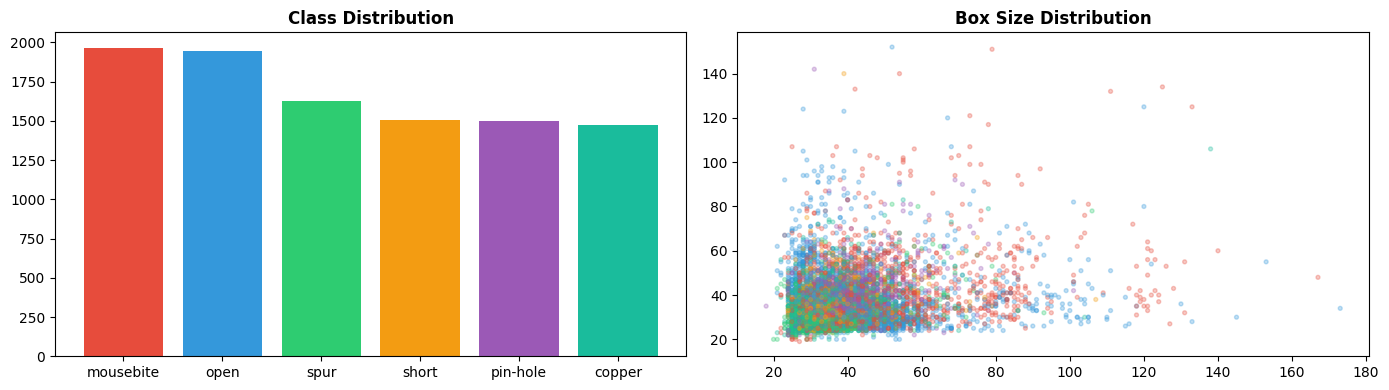

✅ Section 4 done.


In [5]:
CLASS_NAMES  = {1:'open', 2:'short', 3:'mousebite', 4:'spur', 5:'copper', 6:'pin-hole'}
CLASS_COLORS = {1:'#e74c3c', 2:'#3498db', 3:'#2ecc71', 4:'#f39c12', 5:'#9b59b6', 6:'#1abc9c'}

def parse_split_file(split_file):
    pairs = []
    with open(split_file) as f:
        for line in f:
            line = line.strip()
            if not line: continue
            parts = line.split()
            if len(parts) < 2: continue
            ann_path = DATASET_ROOT / parts[1]
            stem     = ann_path.stem
            img_dir  = ann_path.parent.parent / ann_path.parent.name.replace('_not','')
            pairs.append({
                'image_id': stem,
                'test_img': img_dir / f'{stem}_test.jpg',
                'temp_img': img_dir / f'{stem}_temp.jpg',
                'ann_path': ann_path,
            })
    return pairs

trainval_pairs = parse_split_file(DATASET_ROOT / 'trainval.txt')
test_pairs     = parse_split_file(DATASET_ROOT / 'test.txt')
all_pairs      = trainval_pairs + test_pairs
print(f'trainval: {len(trainval_pairs)} | test: {len(test_pairs)} | total: {len(all_pairs)}')

records = []
for pair in tqdm(all_pairs, desc='Parsing'):
    if not pair['ann_path'].exists() or not pair['test_img'].exists(): continue
    with open(pair['ann_path']) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5: continue
            try: x1,y1,x2,y2,cls = int(parts[0]),int(parts[1]),int(parts[2]),int(parts[3]),int(parts[4])
            except: continue
            if cls == 0: continue
            records.append({
                'image_id': pair['image_id'],
                'test_img': str(pair['test_img']),
                'temp_img': str(pair['temp_img']),
                'x1':x1,'y1':y1,'x2':x2,'y2':y2,
                'cls': cls, 'class_name': CLASS_NAMES.get(cls,'unknown'),
            })

df = pd.DataFrame(records)
print(f'Annotations: {len(df)} | Images: {df["image_id"].nunique()}')
print(df['class_name'].value_counts())

fig, axes = plt.subplots(1,2,figsize=(14,4))
cc = df['class_name'].value_counts()
axes[0].bar(cc.index, cc.values, color=[CLASS_COLORS[k] for k in CLASS_NAMES if CLASS_NAMES[k] in cc.index])
axes[0].set_title('Class Distribution', fontweight='bold')
axes[1].scatter(df['x2']-df['x1'], df['y2']-df['y1'], alpha=0.3, s=8,
                c=[CLASS_COLORS.get(c,'#999') for c in df['cls']])
axes[1].set_title('Box Size Distribution', fontweight='bold')
plt.tight_layout(); plt.savefig('class_distribution.png', dpi=150); plt.show()
print('✅ Section 4 done.')


## Section 5 — Difference Imaging

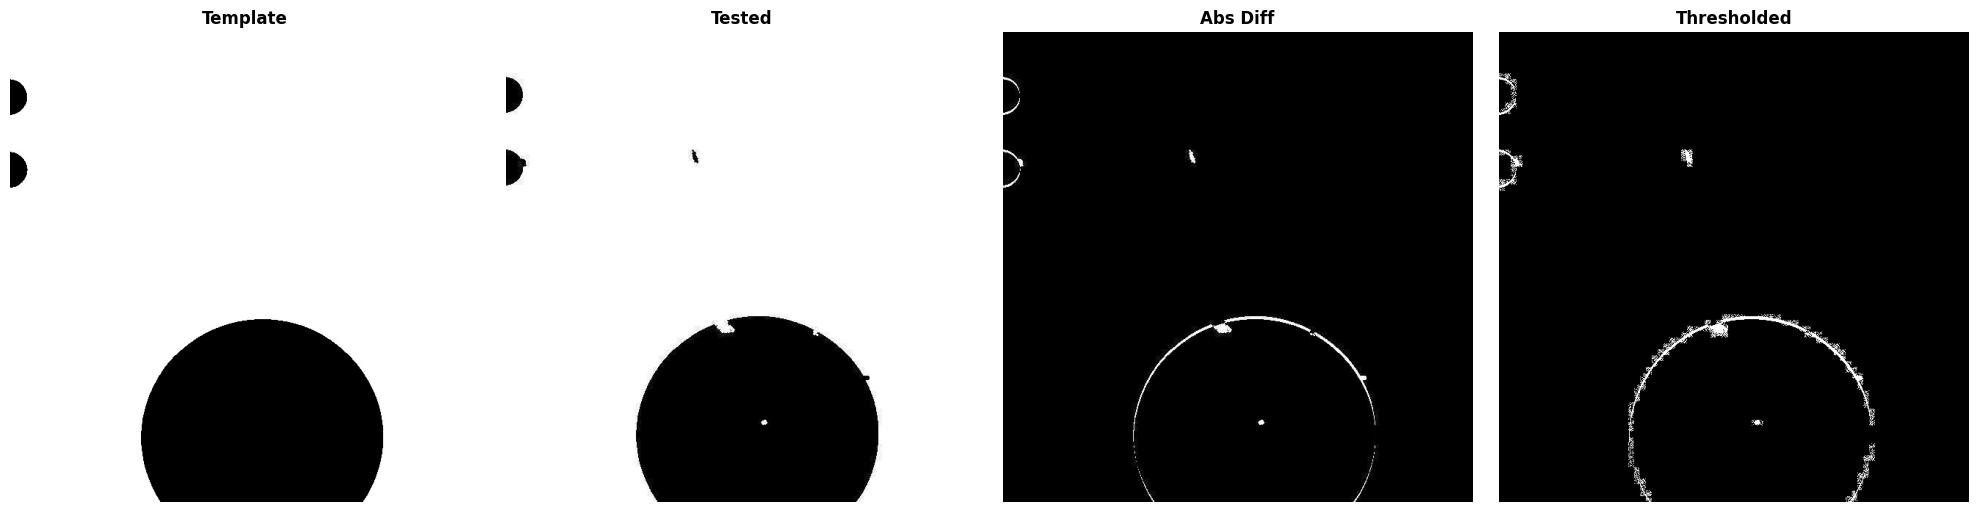

✅ Section 5 done.


In [6]:
def compute_diff_image(test_path, temp_path):
    test = cv2.imread(str(test_path), cv2.IMREAD_GRAYSCALE)
    temp = cv2.imread(str(temp_path), cv2.IMREAD_GRAYSCALE)
    diff = cv2.absdiff(test, temp)
    _, diff_thresh = cv2.threshold(diff, 10, 255, cv2.THRESH_BINARY)
    return test, temp, diff, diff_thresh

row = df.iloc[0]
test,temp,diff,dt = compute_diff_image(row['test_img'], row['temp_img'])
fig, axes = plt.subplots(1,4,figsize=(20,5))
for ax,img,title in zip(axes,[temp,test,diff,dt],
    ['Template','Tested','Abs Diff','Thresholded']):
    ax.imshow(img, cmap='gray'); ax.set_title(title, fontweight='bold'); ax.axis('off')
plt.tight_layout(); plt.savefig('difference_imaging.png', dpi=150); plt.show()
print('✅ Section 5 done.')


## Section 6 — Convert to YOLO Format

In [7]:
OUTPUT_DIR  = Path('pcb_yolo_dataset')
TRAIN_SPLIT = 0.8

state = ckpt_mgr.load_state()

if state.get('yolo_dataset_done') and OUTPUT_DIR.exists():
    print('✅ YOLO dataset already converted — loading split IDs from state.')
    train_ids = state['train_ids']
    val_ids   = state['val_ids']
    test_ids  = state['test_ids']
else:
    for split in ['train','val','test']:
        (OUTPUT_DIR/'images'/split).mkdir(parents=True, exist_ok=True)
        (OUTPUT_DIR/'labels'/split).mkdir(parents=True, exist_ok=True)

    trainval_ids = [p['image_id'] for p in trainval_pairs]
    test_ids     = [p['image_id'] for p in test_pairs]
    random.seed(RANDOM_SEED); random.shuffle(trainval_ids)
    n         = len(trainval_ids)
    train_ids = trainval_ids[:int(n*TRAIN_SPLIT)]
    val_ids   = trainval_ids[int(n*TRAIN_SPLIT):]
    print(f'Train:{len(train_ids)} Val:{len(val_ids)} Test:{len(test_ids)}')

    CLS_MAP    = {1:0,2:1,3:2,4:3,5:4,6:5}
    id_to_rows = defaultdict(list)
    for rec in records: id_to_rows[rec['image_id']].append(rec)

    def convert_to_yolo(x1,y1,x2,y2,iw,ih):
        cx=((x1+x2)/2)/iw; cy=((y1+y2)/2)/ih
        w=(x2-x1)/iw;      h=(y2-y1)/ih
        return np.clip([cx,cy,w,h],0,1)

    def process_split(ids, split):
        skipped=0
        for image_id in tqdm(ids, desc=f'Processing {split}'):
            rows = id_to_rows.get(image_id,[])
            if not rows: skipped+=1; continue
            r0 = rows[0]
            img = cv2.imread(r0['test_img'])
            if img is None: skipped+=1; continue
            ih,iw = img.shape[:2]
            cv2.imwrite(str(OUTPUT_DIR/'images'/split/f'{image_id}.jpg'), img)
            with open(OUTPUT_DIR/'labels'/split/f'{image_id}.txt','w') as lf:
                for r in rows:
                    if r['cls'] not in CLS_MAP: continue
                    cx,cy,w,h = convert_to_yolo(r['x1'],r['y1'],r['x2'],r['y2'],iw,ih)
                    lf.write(f"{CLS_MAP[r['cls']]} {cx:.6f} {cy:.6f} {w:.6f} {h:.6f}\n")
        print(f'  Skipped: {skipped}')

    process_split(train_ids,'train')
    process_split(val_ids,'val')
    process_split(test_ids,'test')

    state.update({'yolo_dataset_done': True,
                  'train_ids': train_ids, 'val_ids': val_ids, 'test_ids': test_ids})
    ckpt_mgr.save_state(state)
    print('✅ Section 6 done.')


Train:800 Val:200 Test:500


Processing train: 100%|██████████| 800/800 [00:02<00:00, 341.98it/s]


  Skipped: 0


Processing val: 100%|██████████| 200/200 [00:00<00:00, 331.31it/s]


  Skipped: 0


Processing test: 100%|██████████| 500/500 [00:01<00:00, 330.56it/s]

  Skipped: 0
✅ Section 6 done.


## Section 7 — Dataset YAML

In [8]:
yaml_path = Path('pcb_dataset.yaml')
dataset_yaml = {
    'path' : str(OUTPUT_DIR.resolve()),
    'train': 'images/train', 'val': 'images/val', 'test': 'images/test',
    'nc'   : 6,
    'names': ['open','short','mousebite','spur','copper','pin-hole']
}
with open(yaml_path,'w') as f:
    yaml.dump(dataset_yaml, f, default_flow_style=False, sort_keys=False)
print(yaml_path.read_text())
print('✅ Section 7 done.')


path: /kaggle/working/pcb_yolo_dataset
train: images/train
val: images/val
test: images/test
nc: 6
names:
- open
- short
- mousebite
- spur
- copper
- pin-hole

✅ Section 7 done.


## Section 8 — Train Classical YOLOv8x (Baseline)

If `yolov8_best.pt` already exists in the checkpoint directory,
training is **skipped** and the weights are loaded directly.  
On Kaggle this persists across sessions automatically.


In [9]:
BASELINE_WEIGHTS_LOCAL = str(CKPT_ROOT / 'yolov8_best.pt')

# ── Restore or train ──────────────────────────────────────────────────────────
existing = ckpt_mgr.load_file('yolov8_best.pt')
existing = ckpt_mgr.load_file('yolov8_best.pt')
print("Existing:", existing)
print("CKPT_ROOT contents:", list(CKPT_ROOT.iterdir()))
state    = ckpt_mgr.load_state()
if existing:
    print(f"✅ YOLOv8 weights found — skipping training.")
    baseline_model = YOLO(str(existing))
else:
    print("Starting YOLOv8x training...")
    base_model = YOLO('yolov8x.pt')
    results = base_model.train(
        data=str(yaml_path), epochs=100, imgsz=640, batch=4,
        patience=20, optimizer='AdamW', lr0=0.001, lrf=0.01,
        cos_lr=True, warmup_epochs=5, weight_decay=0.0005,
        hsv_h=0.015, hsv_s=0.5, hsv_v=0.4,
        degrees=5.0, translate=0.1, scale=0.5,
        fliplr=0.5, flipud=0.1, mosaic=1.0, mixup=0.1, copy_paste=0.1,
        box=7.5, cls=0.5, dfl=1.5, iou=0.33, conf=0.001,
        project='pcb_runs', name='yolov8x_baseline',
        exist_ok=True, pretrained=True, seed=RANDOM_SEED,
        device=0 if torch.cuda.is_available() else 'cpu',
        amp=True, cache='disk', workers=4,
        save=True, save_period=10, plots=True, verbose=True,
    )
    import glob
    candidates = glob.glob('**/best.pt', recursive=True)
    best_src = sorted(candidates)[-1]
    print(f"Found: {best_src}")
    ckpt_mgr.save_file(best_src, 'yolov8_best.pt')
    baseline_model = YOLO(BASELINE_WEIGHTS_LOCAL)
    state['yolo_trained'] = True
    ckpt_mgr.save_state(state)
    print('✅ Baseline training complete.')

BASELINE_WEIGHTS = BASELINE_WEIGHTS_LOCAL
print(f"✅ Baseline loaded: {BASELINE_WEIGHTS}")


Existing: None
CKPT_ROOT contents: [PosixPath('/kaggle/working/checkpoints/pipeline_state.pkl')]
Starting YOLOv8x training...
Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=disk, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=0.001, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=pcb_dataset.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.1, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=640, int8=False, iou=0.33, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolov8x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.

## Section 9 - Extract Per-Box Features (RoI Align)

Features are cached as `features.npz` on Drive.  Re-running after a session
crash skips extraction entirely.


In [10]:
from torchvision.ops import roi_align

class BoxFeatureExtractor(nn.Module):
    def __init__(self, yolo_model, layer_idx=15, roi_size=7):
        super().__init__()
        self.model    = yolo_model.model   # full ultralytics DetectionModel
        self.roi_size = roi_size
        self.output_dim = None
        self._feat_map  = None

        # Freeze all parameters
        for p in self.model.parameters():
            p.requires_grad = False

        # Register hook on the target layer to grab its output
        target_layer = self.model.model[layer_idx]
        self._hook = target_layer.register_forward_hook(self._save_feat)

    def _save_feat(self, module, input, output):
        # Some layers output a list/tuple (e.g. Detect); grab first element
        if isinstance(output, (list, tuple)):
            self._feat_map = output[0]
        else:
            self._feat_map = output

    def forward(self, images, boxes_list):
        _, _, iH, iW = images.shape

        with torch.no_grad():
            self.model(images)          # full forward pass; hook fires internally

        feat_map = self._feat_map       # captured by hook
        B, C, fH, fW = feat_map.shape

        scale_x = fW / iW
        scale_y = fH / iH

        rois = []
        for i, boxes in enumerate(boxes_list):
            if len(boxes) == 0:
                continue
            scaled = boxes.clone().float()
            scaled[:, 0] *= scale_x;  scaled[:, 2] *= scale_x
            scaled[:, 1] *= scale_y;  scaled[:, 3] *= scale_y
            batch_idx = torch.full((len(boxes), 1), i, dtype=torch.float32)
            rois.append(torch.cat([batch_idx, scaled], dim=1))

        if not rois:
            return torch.zeros(0, C * self.roi_size * self.roi_size,
                               device=feat_map.device)

        rois     = torch.cat(rois, dim=0).to(feat_map.device)
        roi_feat = roi_align(feat_map, rois,
                             output_size=(self.roi_size, self.roi_size),
                             spatial_scale=1.0)
        flat = roi_feat.flatten(1)
        self.output_dim = flat.shape[1]
        return flat

    def __del__(self):
        # Clean up hook when object is destroyed
        if hasattr(self, '_hook'):
            self._hook.remove()


# Usage
extractor = BoxFeatureExtractor(baseline_model, layer_idx=15, roi_size=7)
extractor.eval()
print("✅ BoxFeatureExtractor ready")

test_tensor = torch.zeros(1, 3, 640, 640)
dummy_box   = torch.tensor([[100., 100., 200., 200.]])
feat        = extractor(test_tensor, [dummy_box])
print(f"Per-box feature dim: {feat.shape[1]}")


✅ BoxFeatureExtractor ready
Per-box feature dim: 15680


In [11]:
# ── Load cached features or extract ──────────────────────────────────────────
X, y = ckpt_mgr.load_features()

if X is None:
    CLASS_NAMES_LIST = ['open','short','mousebite','spur','copper','pin-hole']
    N_CLASSES        = 6
    IMG_SIZE         = 640
    MAX_IMAGES       = 2000    # increase for more coverage

    print(f"Extracting per-box features from {MAX_IMAGES} images...")
    all_features, all_labels = [], []

    train_imgs  = sorted((OUTPUT_DIR/'images'/'train').glob('*.jpg'))
    random.seed(RANDOM_SEED)
    sample_imgs = random.sample(train_imgs, min(MAX_IMAGES, len(train_imgs)))

    extractor.eval()
    for img_path in tqdm(sample_imgs, desc="Extracting"):
        lbl_path = Path(str(img_path).replace('images','labels').replace('.jpg','.txt'))
        if not lbl_path.exists(): continue
        img = cv2.imread(str(img_path))
        if img is None: continue
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        ih, iw = img.shape[:2]
        boxes, labels = [], []
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 5: continue
                cls_id = int(parts[0])
                cx,cy,w,h = float(parts[1]),float(parts[2]),float(parts[3]),float(parts[4])
                x1=(cx-w/2)*iw; y1=(cy-h/2)*ih; x2=(cx+w/2)*iw; y2=(cy+h/2)*ih
                boxes.append([x1,y1,x2,y2]); labels.append(cls_id)
        if not boxes: continue
        t       = torch.from_numpy(img).permute(2,0,1).float()/255.0
        boxes_t = torch.tensor(boxes, dtype=torch.float32)
        with torch.no_grad():
            feats = extractor(t.unsqueeze(0), [boxes_t])
        all_features.append(feats.numpy()); all_labels.extend(labels)

    X = np.vstack(all_features); y = np.array(all_labels)
    ckpt_mgr.save_features(X, y)
    print(f"Extracted {len(y)} boxes, feature dim={X.shape[1]}")
else:
    print(f"Loaded {len(y)} boxes, feature dim={X.shape[1]}")

CLASS_NAMES_LIST = ['open','short','mousebite','spur','copper','pin-hole']
N_CLASSES = 6; IMG_SIZE = 640
print(f"Class distribution: {np.bincount(y)}")


Extracting per-box features from 2000 images...


Extracting: 100%|██████████| 800/800 [18:45<00:00,  1.41s/it]


✓ Features saved → /kaggle/working/checkpoints/features.npz  X=(5514, 15680)  y=(5514,)
Extracted 5514 boxes, feature dim=15680
Class distribution: [1024  830 1121  910  804  825]


## Section 10 — Quantum Detection Head

In [12]:
N_QUBITS   = 8
N_Q_LAYERS = 3

dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="torch")
def quantum_classification_circuit(inputs, weights):
    qml.AngleEmbedding(inputs, wires=range(N_QUBITS), rotation="Y")
    qml.StronglyEntanglingLayers(weights, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

print(f"Circuit parameters: {N_Q_LAYERS * N_QUBITS * 3}")


class QuantumDetectionHead(nn.Module):
    """
    Projection → LayerNorm → tanh*π → quantum circuit → linear readout.
    LayerNorm stabilises the qubit input angles across batches.
    """
    def __init__(self, in_dim, n_qubits=N_QUBITS, n_layers=N_Q_LAYERS, n_classes=N_CLASSES):
        super().__init__()
        self.n_qubits = n_qubits
        self.projection = nn.Sequential(
            nn.Linear(in_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Linear(64, n_qubits),
            nn.Tanh()           # → [-1,1]; multiplied by π below
        )
        weight_shapes = {"weights": (n_layers, n_qubits, 3)}
        self.q_layer  = qml.qnn.TorchLayer(quantum_classification_circuit, weight_shapes)
        self.readout  = nn.Linear(n_qubits, n_classes)
        nn.init.xavier_uniform_(self.readout.weight, gain=0.1)

    def forward(self, x):
        projected = self.projection(x) * torch.pi
        q_out     = torch.stack([self.q_layer(p) for p in projected])
        return self.readout(q_out)


class ClassicalDetectionHead(nn.Module):
    def __init__(self, in_dim, n_classes=N_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(128, 64),     nn.ReLU(),
            nn.Linear(64, n_classes)
        )
    def forward(self, x): return self.net(x)


FEAT_DIM = X.shape[1]
q_head = QuantumDetectionHead(in_dim=FEAT_DIM)
c_head = ClassicalDetectionHead(in_dim=FEAT_DIM)

print(f"Quantum head params  : {sum(p.numel() for p in q_head.parameters()):,}")
print(f"Classical head params: {sum(p.numel() for p in c_head.parameters()):,}")
print("✅ Section 10 done.")


Circuit parameters: 72
Quantum head params  : 4,032,070
Classical head params: 2,015,814
✅ Section 10 done.


## Section 11 — Train Quantum + Classical Heads (Resumable)

`train_head_resumable()` will:
1. Check Drive for the latest epoch snapshot matching `{prefix}epoch_*.pt`
2. Load model + optimizer + scheduler state → resume from that epoch
3. Save a snapshot every `save_every` epochs **and** the best model whenever
   validation accuracy improves
4. All snapshots go to Drive immediately

Re-run this cell after a session crash — it picks up exactly where it left off.


In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

# ── Prepare data ──────────────────────────────────────────────────────────────
feat_scaler = StandardScaler()
X_scaled    = feat_scaler.fit_transform(X)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y
)
print(f"Train: {len(y_tr)} | Val: {len(y_val)}")

Xtr = torch.tensor(X_tr,  dtype=torch.float32)
ytr = torch.tensor(y_tr,  dtype=torch.long)
Xvl = torch.tensor(X_val, dtype=torch.float32)
yvl = torch.tensor(y_val, dtype=torch.long)

class_weights = compute_class_weight('balanced', classes=np.arange(N_CLASSES), y=y_tr)
class_weights = torch.tensor(class_weights, dtype=torch.float32)
print(f"Class weights: {np.round(class_weights.numpy(), 3)}")


Train: 4411 | Val: 1103
Class weights: [      0.898       1.107        0.82        1.01       1.143       1.114]


In [14]:
def train_head_resumable(head, name, Xtr, ytr, Xvl, yvl,
                         epochs=80, lr=1e-3, batch_size=32,
                         class_weights=None, save_every=5,
                         force_retrain=False):
    """
    Trains `head` with full Drive-backed resumability.

    Parameters
    ----------
    head          : nn.Module to train (modified in-place)
    name          : short label, e.g. 'quantum' or 'classical'
    save_every    : save an epoch snapshot to Drive every N epochs
    force_retrain : if True, ignore all existing checkpoints and start fresh
    """
    prefix  = f'{name.lower()}_'
    best_ck = f'{prefix}best.pt'
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)

    opt   = torch.optim.Adam(head.parameters(), lr=lr, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    tr_losses, val_losses, tr_accs, val_accs = [], [], [], []
    start_epoch = 0

    # ── Resume: find latest epoch snapshot ───────────────────────────────────
    if force_retrain:
        print(f"[{name}] force_retrain=True — starting fresh from epoch 0")
    else:
        latest_snap = ckpt_mgr.latest_epoch_ckpt(prefix)
        if latest_snap:
            start_epoch, metrics = ckpt_mgr.load_model(latest_snap, head, opt, sched)
            tr_losses  = metrics.get('tr_losses',  [])
            val_losses = metrics.get('val_losses', [])
            tr_accs    = metrics.get('tr_accs',    [])
            val_accs   = metrics.get('val_accs',   [])
            print(f"[{name}] Resuming from epoch {start_epoch}/{epochs}")
        else:
            # Also try best checkpoint (if training was complete but epoch snaps pruned)
            ep, metrics = ckpt_mgr.load_model(best_ck, head)
            if ep > 0:
                start_epoch = ep
                tr_losses  = metrics.get('tr_losses',  [])
                val_losses = metrics.get('val_losses', [])
                tr_accs    = metrics.get('tr_accs',    [])
                val_accs   = metrics.get('val_accs',   [])
                print(f"[{name}] Loaded best ckpt, epoch={ep}")

        if start_epoch >= epochs:
            print(f"[{name}] Already fully trained ({start_epoch}/{epochs} epochs). Loading best.")
            ckpt_mgr.load_model(best_ck, head)
            return tr_losses, val_losses, tr_accs, val_accs

    best_acc = max(val_accs) if val_accs else 0.0
    N        = len(Xtr)

    for ep in range(start_epoch, epochs):
        # ── Train one epoch ───────────────────────────────────────────────────
        head.train()
        perm      = torch.randperm(N)
        ep_loss   = 0.0; ep_correct = 0; n_batches = 0

        for i in range(0, N, batch_size):
            idx     = perm[i:i+batch_size]
            xb, yb  = Xtr[idx], ytr[idx]
            opt.zero_grad()
            logits  = head(xb)
            loss    = loss_fn(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(head.parameters(), max_norm=1.0)
            opt.step()
            ep_loss     += loss.item()
            ep_correct  += (logits.argmax(1) == yb).sum().item()
            n_batches   += 1

        sched.step()
        avg_loss  = ep_loss / n_batches
        train_acc = ep_correct / N
        tr_losses.append(avg_loss)
        tr_accs.append(train_acc)

        # ── Validate ──────────────────────────────────────────────────────────
        head.eval()
        with torch.no_grad():
            preds    = head(Xvl).argmax(1)
            val_acc  = (preds == yvl).float().mean().item()
            val_loss = loss_fn(head(Xvl), yvl).item()
            n_unique = len(torch.unique(preds))
        val_losses.append(val_loss)
        val_accs.append(val_acc)

        metrics_now = {
            'tr_losses': tr_losses, 'val_losses': val_losses,
            'tr_accs':   tr_accs,   'val_accs':   val_accs,
        }

        # ── Save best ─────────────────────────────────────────────────────────
        if val_acc > best_acc:
            best_acc = val_acc
            ckpt_mgr.save_model(best_ck, head, epoch=ep+1, metrics=metrics_now)
            print(f"  [{name}] ★ New best val_acc={best_acc:.4f} at epoch {ep+1}")

        # ── Periodic epoch snapshot ───────────────────────────────────────────
        if (ep+1) % save_every == 0:
            snap_name = f'{prefix}epoch_{ep+1}.pt'
            ckpt_mgr.save_model(snap_name, head, opt, sched,
                                 epoch=ep+1, metrics=metrics_now, keep_last=3)
            print(f"  [{name}] Epoch {ep+1:3d}/{epochs}  "
                  f"loss={avg_loss:.4f}  val_acc={val_acc:.4f}  "
                  f"unique_preds={n_unique}")

    # ── Restore best at end ───────────────────────────────────────────────────
    ckpt_mgr.load_model(best_ck, head)
    print(f"\n  [{name}] Training complete.  Best val accuracy: {best_acc:.4f}")
    return tr_losses, val_losses, tr_accs, val_accs


# ── Run training ──────────────────────────────────────────────────────────────
print("\nTraining Classical Detection Head...")
c_losses, c_val_losses, c_tr_accs, c_accs = train_head_resumable(
    c_head, "classical", Xtr, ytr, Xvl, yvl,
    epochs=80, lr=1e-3, class_weights=class_weights, save_every=5,
    force_retrain=True      # ← set to False to resume normally
)

print("\nTraining Quantum Detection Head...")
q_losses, q_val_losses, q_tr_accs, q_accs = train_head_resumable(
    q_head, "quantum", Xtr, ytr, Xvl, yvl,
    epochs=80, lr=1e-4,
    class_weights=class_weights, save_every=5,
    force_retrain=True
)

print(f"\nFinal Classical Val Accuracy : {c_accs[-1]:.4f}")
print(f"Final Quantum   Val Accuracy : {q_accs[-1]:.4f}")


Training Classical Detection Head...
[classical] force_retrain=True — starting fresh from epoch 0
  💾 Saved: classical_best.pt  (epoch=1)
  [classical] ★ New best val_acc=0.9692 at epoch 1
  💾 Saved: classical_best.pt  (epoch=2)
  [classical] ★ New best val_acc=0.9864 at epoch 2
  💾 Saved: classical_epoch_5.pt  (epoch=5)
  [classical] Epoch   5/80  loss=0.0086  val_acc=0.9837  unique_preds=6
  💾 Saved: classical_best.pt  (epoch=7)
  [classical] ★ New best val_acc=0.9882 at epoch 7
  💾 Saved: classical_epoch_10.pt  (epoch=10)
  [classical] Epoch  10/80  loss=0.0234  val_acc=0.9873  unique_preds=6
  💾 Saved: classical_best.pt  (epoch=12)
  [classical] ★ New best val_acc=0.9918 at epoch 12
  💾 Saved: classical_epoch_15.pt  (epoch=15)
  [classical] Epoch  15/80  loss=0.0209  val_acc=0.9828  unique_preds=6
  💾 Saved: classical_epoch_20.pt  (epoch=20)
  🗑  Pruned old snapshot: classical_epoch_5.pt
  [classical] Epoch  20/80  loss=0.0319  val_acc=0.9828  unique_preds=6
  💾 Saved: classical_e

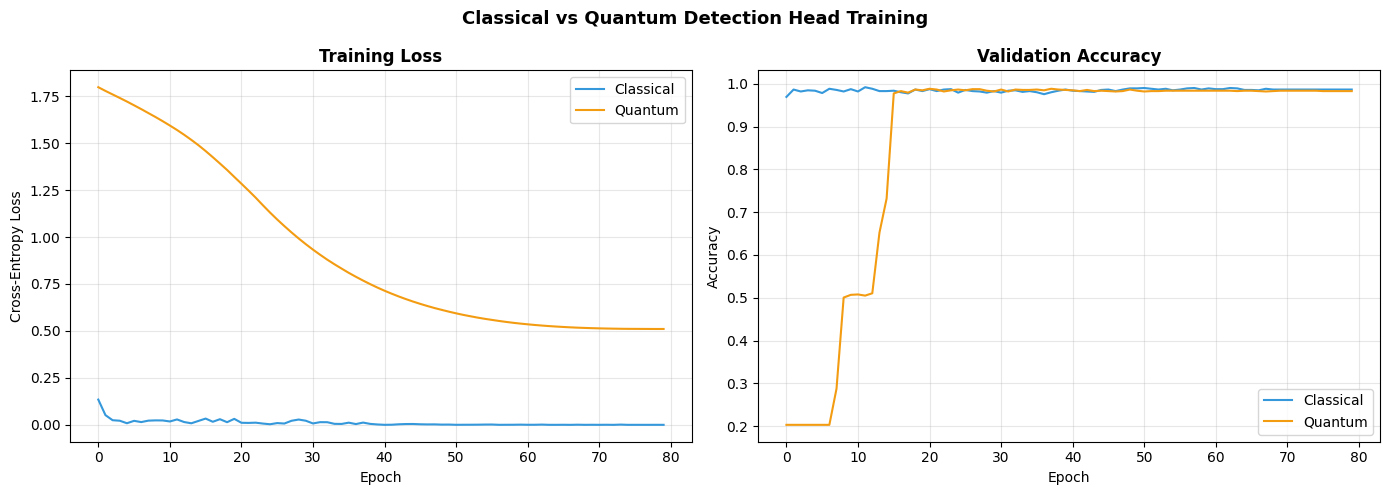

In [15]:
# ── Training curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1,2,figsize=(14,5))
axes[0].plot(c_losses,  label='Classical', color='#3498db', linewidth=1.5)
axes[0].plot(q_losses,  label='Quantum',   color='#f39c12', linewidth=1.5)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(c_accs, label='Classical', color='#3498db', linewidth=1.5)
axes[1].plot(q_accs, label='Quantum',   color='#f39c12', linewidth=1.5)
axes[1].set_title('Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle('Classical vs Quantum Detection Head Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('qdh_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()


## Section 12 — Evaluate & Compare


  Classical Detection Head
              precision    recall  f1-score   support

        open       0.98      0.99      0.98       205
       short       0.99      1.00      0.99       166
   mousebite       1.00      0.98      0.99       224
        spur       0.99      0.99      0.99       182
      copper       1.00      1.00      1.00       161
    pin-hole       1.00      1.00      1.00       165

    accuracy                           0.99      1103
   macro avg       0.99      0.99      0.99      1103
weighted avg       0.99      0.99      0.99      1103


  Quantum Detection Head
              precision    recall  f1-score   support

        open       0.98      1.00      0.99       205
       short       0.99      0.98      0.99       166
   mousebite       0.97      0.98      0.98       224
        spur       0.99      0.99      0.99       182
      copper       1.00      0.99      1.00       161
    pin-hole       1.00      0.98      0.99       165

    accuracy           

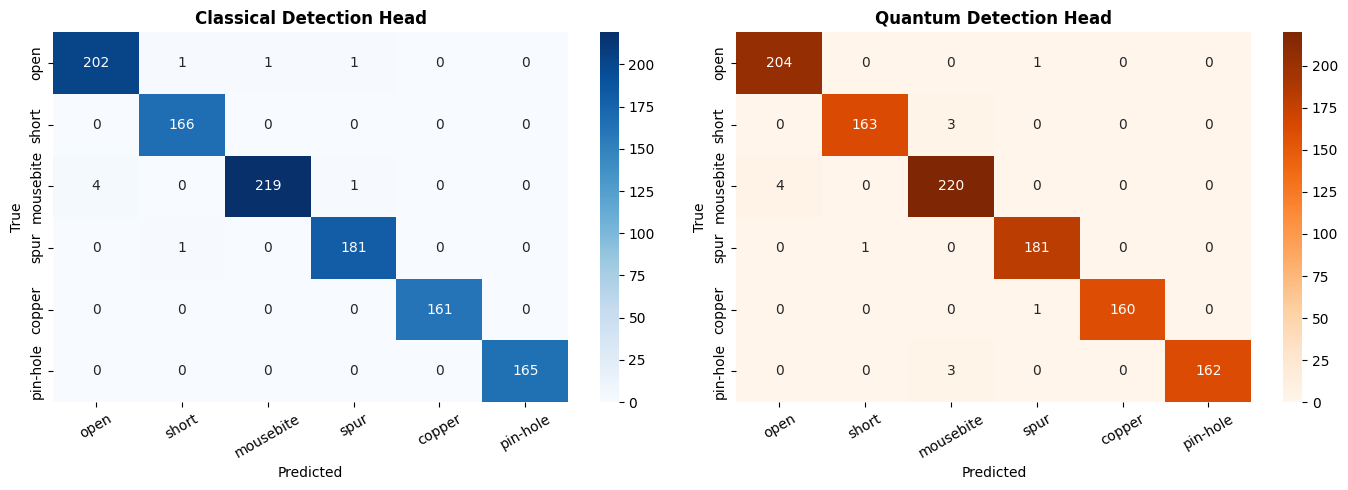

Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 113 layers, 68,129,346 parameters, 0 gradients, 257.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 25.7±6.4 MB/s, size: 48.3 KB)
val: Scanning /kaggle/working/pcb_yolo_dataset/labels/test... 500 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 500/500 771.5it/s 0.6s
val: New cache created: /kaggle/working/pcb_yolo_dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 32/32 1.0it/s 31.3s
                   all        500       3140      0.929      0.902      0.919      0.495
                  open        482        659      0.899      0.933      0.902      0.448
                 short        368        478      0.845      0.835      0.839      0.459
             mousebite        413        586      0.938      0.922      0.942      0.459
                  spur        373        483       0.

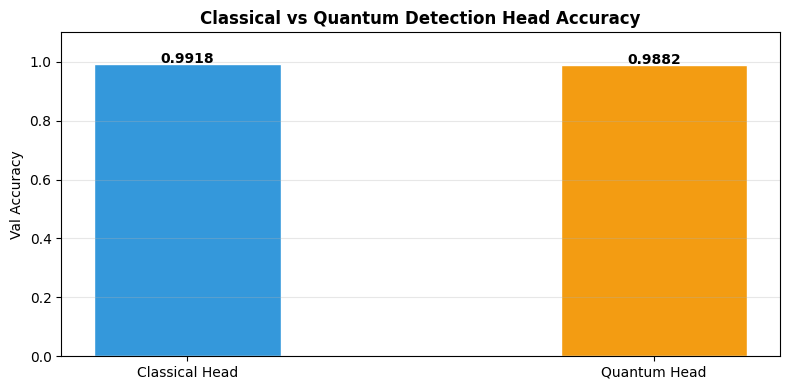

✅ Section 12 done.


In [16]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def evaluate_head(head, Xvl, yvl, name):
    head.eval()
    with torch.no_grad():
        preds = head(Xvl).argmax(1).numpy()
    report = classification_report(yvl.numpy(), preds,
                                   target_names=CLASS_NAMES_LIST,
                                   zero_division=0)
    print(f"\n{'='*50}")
    print(f"  {name} Detection Head")
    print('='*50)
    print(report)
    return preds

c_preds = evaluate_head(c_head, Xvl, yvl, "Classical")
q_preds = evaluate_head(q_head, Xvl, yvl, "Quantum")

# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1,2,figsize=(14,5))
for ax, preds, title, cmap in [
    (axes[0], c_preds, 'Classical Detection Head', 'Blues'),
    (axes[1], q_preds, 'Quantum Detection Head',   'Oranges'),
]:
    cm = confusion_matrix(yvl.numpy(), preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=CLASS_NAMES_LIST, yticklabels=CLASS_NAMES_LIST)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('qdh_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# ── YOLOv8 mAP ───────────────────────────────────────────────────────────────
test_metrics = baseline_model.val(data=str(yaml_path), split='test',
                                   iou=0.33, conf=0.25, imgsz=640, verbose=True)

p = test_metrics.box.mp; r = test_metrics.box.mr
print('\n========== YOLO BASELINE (TEST SET) ==========')
print(f'mAP@0.5   : {test_metrics.box.map50:.4f}')
print(f'Precision : {p:.4f}')
print(f'Recall    : {r:.4f}')
print(f'F1        : {2*p*r/(p+r+1e-9):.4f}')

# ── Summary bar chart ─────────────────────────────────────────────────────────
c_acc = (torch.tensor(c_preds) == yvl).float().mean().item()
q_acc = (torch.tensor(q_preds) == yvl).float().mean().item()

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(['Classical Head','Quantum Head'], [c_acc, q_acc],
       color=['#3498db','#f39c12'], width=0.4, edgecolor='white')
for i,v in enumerate([c_acc, q_acc]):
    ax.text(i, v+0.005, f'{v:.4f}', ha='center', fontweight='bold')
ax.set_ylim(0,1.1); ax.set_ylabel('Val Accuracy')
ax.set_title('Classical vs Quantum Detection Head Accuracy', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('qdh_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Section 12 done.')


## Section 13 — Inference & Visualize

In [17]:
from torchvision.ops import roi_align

class BoxFeatureExtractor(nn.Module):
    def __init__(self, yolo_model, layer_idx=15, roi_size=7):
        super().__init__()
        self.model    = yolo_model.model
        self.roi_size = roi_size
        self.output_dim = None
        self._feat_map  = None

        for p in self.model.parameters():
            p.requires_grad = False

        target_layer = self.model.model[layer_idx]
        self._hook = target_layer.register_forward_hook(self._save_feat)

    def _save_feat(self, module, input, output):
        if isinstance(output, (list, tuple)):
            self._feat_map = output[0]
        else:
            self._feat_map = output

    def forward(self, images, boxes_list):
        _, _, iH, iW = images.shape

        with torch.no_grad():
            self.model(images)

        feat_map = self._feat_map
        B, C, fH, fW = feat_map.shape
        device = feat_map.device      # ← get device from feature map

        scale_x = fW / iW
        scale_y = fH / iH

        rois = []
        for i, boxes in enumerate(boxes_list):
            if len(boxes) == 0:
                continue
            scaled = boxes.clone().float().to(device)   # ← move boxes to device
            scaled[:, 0] *= scale_x;  scaled[:, 2] *= scale_x
            scaled[:, 1] *= scale_y;  scaled[:, 3] *= scale_y
            batch_idx = torch.full((len(boxes), 1), i,
                                   dtype=torch.float32, device=device)  # ← create on device
            rois.append(torch.cat([batch_idx, scaled], dim=1))

        if not rois:
            return torch.zeros(0, C * self.roi_size * self.roi_size,
                               device=device)

        rois     = torch.cat(rois, dim=0)               # already on device
        roi_feat = roi_align(feat_map, rois,
                             output_size=(self.roi_size, self.roi_size),
                             spatial_scale=1.0)
        flat = roi_feat.flatten(1)
        self.output_dim = flat.shape[1]
        return flat

    def __del__(self):
        if hasattr(self, '_hook'):
            self._hook.remove()


# Re-initialise extractor and test
extractor = BoxFeatureExtractor(baseline_model, layer_idx=15, roi_size=7).to(DEVICE)
extractor.eval()

test_tensor = torch.zeros(1, 3, 640, 640).to(DEVICE)
dummy_box   = torch.tensor([[100., 100., 200., 200.]]).to(DEVICE)
feat        = extractor(test_tensor, [dummy_box])
print(f"✅ BoxFeatureExtractor ready — per-box feature dim: {feat.shape[1]}")

✅ BoxFeatureExtractor ready — per-box feature dim: 15680


## Section 14 — Export

In [18]:
# ── Save all final artefacts to checkpoint dir ────────────────────────────────
torch.save(q_head.state_dict(),    'quantum_detection_head.pt')
torch.save(c_head.state_dict(),    'classical_detection_head.pt')
torch.save(extractor.state_dict(), 'box_feature_extractor.pt')

with open('feat_scaler_qdh.pkl', 'wb') as f:
    pickle.dump(feat_scaler, f)

for fname in ['quantum_detection_head.pt', 'classical_detection_head.pt',
              'box_feature_extractor.pt',   'feat_scaler_qdh.pkl']:
    ckpt_mgr.save_file(fname, fname)

# Export YOLOv8 backbone to ONNX
onnx_path = baseline_model.export(format='onnx', imgsz=640, opset=17, simplify=True)
print(f'ONNX: {onnx_path}')

print('\n' + '='*55)
print('  PCB QUANTUM DETECTION HEAD — FINAL SUMMARY')
print('='*55)
print(f'  Environment    : {ENV}')
print(f'  Checkpoint dir : {CKPT_ROOT}')
print(f'  Backbone       : YOLOv8x (frozen, classical)')
print(f'  Classification : Quantum circuit ({N_QUBITS} qubits, {N_Q_LAYERS} layers)')
print(f'  Classes        : {", ".join(CLASS_NAMES_LIST)}')
print(f'  Classical head : {c_accs[-1]:.4f} val accuracy')
print(f'  Quantum head   : {q_accs[-1]:.4f} val accuracy')
print('='*55)
ckpt_mgr.list()
print('✅ All done!')


✓ Saved → /kaggle/working/checkpoints/quantum_detection_head.pt
✓ Saved → /kaggle/working/checkpoints/classical_detection_head.pt
✓ Saved → /kaggle/working/checkpoints/box_feature_extractor.pt
✓ Saved → /kaggle/working/checkpoints/feat_scaler_qdh.pkl
Ultralytics 8.4.37 🚀 Python-3.12.12 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/

PyTorch: starting from '/kaggle/working/checkpoints/yolov8_best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (130.4 MB)
requirements: Ultralytics requirements ['onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 12 packages in 272ms
 Downloaded onnxruntime-gpu
Prepared 2 packages in 2.41s
Installed 2 packages in 16ms
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.91

requirements: AutoUpdate success ✅ 3.7s
WARNING

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
#  DOWNLOAD ALL OUTPUTS  —  paste this as a new cell at the end of your notebook
# ══════════════════════════════════════════════════════════════════════════════
import os, shutil, glob
from pathlib import Path

KAGGLE_WORKING = Path('/kaggle/working')
ZIP_NAME       = 'all_outputs'
ZIP_PATH       = KAGGLE_WORKING / ZIP_NAME          # → /kaggle/working/all_outputs
STAGE_DIR      = Path('/tmp/download_stage')
STAGE_DIR.mkdir(parents=True, exist_ok=True)

# ── 1. Model weights & scaler ─────────────────────────────────────────────────
MODEL_FILES = [
    'quantum_detection_head.pt',
    'classical_detection_head.pt',
    'box_feature_extractor.pt',
    'feat_scaler_qdh.pkl',
]

# ── 2. YOLOv8 best weights (saved by CheckpointManager) ──────────────────────
CKPT_FILES = [
    str(CKPT_ROOT / 'yolov8_best.pt'),          # CKPT_ROOT is defined earlier in notebook
    str(CKPT_ROOT / 'pipeline_state.pkl'),
]

# ── 3. Plots / PNGs ───────────────────────────────────────────────────────────
PLOT_FILES = [
    'qdh_training_curves.png',
    'qdh_confusion_matrices.png',
    'qdh_accuracy_comparison.png',
    'qdh_inference_results.png',
]

# ── 4. Config & ONNX export ───────────────────────────────────────────────────
MISC_FILES = [
    'pcb_dataset.yaml',
]

# ── 5. Any ONNX file produced by baseline_model.export() ─────────────────────
ONNX_FILES = glob.glob(str(KAGGLE_WORKING / '**/*.onnx'), recursive=True)
ONNX_FILES += glob.glob(str(KAGGLE_WORKING / '*.onnx'))

# ── 6. Checkpoint dir contents (catches anything else CheckpointManager saved) ─
CKPT_GLOB = glob.glob(str(CKPT_ROOT / '*'))

ALL_FILES = (
    MODEL_FILES
    + CKPT_FILES
    + PLOT_FILES
    + MISC_FILES
    + ONNX_FILES
    + CKPT_GLOB
)

# ── Copy everything found into the staging dir ────────────────────────────────
copied, missing = [], []

for f in ALL_FILES:
    p = Path(f)
    if p.exists() and p.is_file():
        dest = STAGE_DIR / p.name
        # Avoid silent overwrites from duplicate filenames
        if dest.exists():
            dest = STAGE_DIR / f"{p.parent.name}__{p.name}"
        shutil.copy2(p, dest)
        copied.append(str(p))
    else:
        missing.append(str(f))

print(f"\n{'='*55}")
print(f"  FILES STAGED FOR DOWNLOAD : {len(copied)}")
print(f"{'='*55}")
for f in copied:
    size_kb = Path(f).stat().st_size / 1024
    print(f"  ✓  {Path(f).name:<45}  ({size_kb:,.1f} KB)")

if missing:
    print(f"\n  ✗  Not found (skipped):")
    for f in missing:
        print(f"       {f}")

# ── Zip the staging dir → /kaggle/working/all_outputs.zip ─────────────────────
shutil.make_archive(str(ZIP_PATH), 'zip', str(STAGE_DIR))
zip_size_mb = (ZIP_PATH.with_suffix('.zip')).stat().st_size / (1024 * 1024)
print(f"\n📦  all_outputs.zip  ({zip_size_mb:.2f} MB)")
print(f"    Saved to: {ZIP_PATH}.zip")

# ── On Kaggle the zip is in /kaggle/working/ — visible in the Output panel ───
print("\n✅  Done!  Go to:  Notebook → Output (right panel) → all_outputs.zip → Download")

# ── Optional: also trigger browser download if running on Colab by mistake ────
try:
    from google.colab import files
    files.download(str(ZIP_PATH) + '.zip')
except ImportError:
    pass   # On Kaggle — use the Output panel instead


  FILES STAGED FOR DOWNLOAD : 27
  ✓  quantum_detection_head.pt                      (15,755.6 KB)
  ✓  classical_detection_head.pt                    (7,877.5 KB)
  ✓  box_feature_extractor.pt                       (266,215.9 KB)
  ✓  feat_scaler_qdh.pkl                            (368.0 KB)
  ✓  yolov8_best.pt                                 (133,520.8 KB)
  ✓  pipeline_state.pkl                             (16.2 KB)
  ✓  qdh_training_curves.png                        (101.1 KB)
  ✓  qdh_confusion_matrices.png                     (85.5 KB)
  ✓  qdh_accuracy_comparison.png                    (32.9 KB)
  ✓  pcb_dataset.yaml                               (0.2 KB)
  ✓  yolov8_best.onnx                               (266,409.0 KB)
  ✓  quantum_epoch_80.pt                            (47,269.5 KB)
  ✓  quantum_best.pt                                (15,756.2 KB)
  ✓  yolov8_best.pt                                 (133,520.8 KB)
  ✓  box_feature_extractor.pt                       (266,215.9

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>